# Genomic sequence analysis

This notebook is a workflow for analysing genomic sequence data, including data acquisition, loading,  preprocessing; train-test split and an initial exploratory visualisation of sequence length distribution.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches # For manual legend creation if needed
import requests
import zipfile
import os
from sklearn.model_selection import train_test_split

# --- Configuration --- #
URL = "https://cloud.uni-jena.de/s/9BWwdkBCKYsi6yB/download"
ZIP_FILENAME = "downloaded_data.zip"
EXTRACTED_DIR = "Hackathon: VizAvalanche"
CSV_FILENAME = "collected_data.csv"
DATASET_PATH = os.path.join(EXTRACTED_DIR, CSV_FILENAME)


## 1. Data Acquisition

We'll download the dataset from the specified URL using Python's `requests` library and then unzip it using `zipfile`.

In [4]:
# --- Download the dataset ---
print(f"Downloading dataset from {URL}...")
try:
    response = requests.get(URL, stream=True)
    response.raise_for_status() # Raise an exception for bad status codes

    with open(ZIP_FILENAME, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"File '{ZIP_FILENAME}' downloaded successfully.")
except requests.exceptions.RequestException as e:
    print(f"Error downloading file: {e}")

# --- Unzip the dataset ---
print(f"Unzipping '{ZIP_FILENAME}'...")
try:
    with zipfile.ZipFile(ZIP_FILENAME, 'r') as zip_ref:
        zip_ref.extractall(".") # Extract to current directory
    print(f"'{ZIP_FILENAME}' unzipped successfully. Files extracted to '{EXTRACTED_DIR}'.")
except zipfile.BadZipFile:
    print(f"Error: '{ZIP_FILENAME}' is not a valid ZIP file.")
except FileNotFoundError:
    print(f"Error: The file '{ZIP_FILENAME}' was not found. Please ensure it was downloaded correctly.")
except Exception as e:
    print(f"An error occurred during unzipping: {e}")


File 'downloaded_data.zip' downloaded successfully.
Unzipping 'downloaded_data.zip'...
'downloaded_data.zip' unzipped successfully. Files extracted to 'Hackathon: VizAvalanche'.


## 2. Data Loading

Load the `collected_data.csv` file into a pandas DataFrame and display initial information.

In [6]:
# --- Load the dataset into a pandas DataFrame ---
print(f"Loading dataset from {DATASET_PATH}...")
try:
    df = pd.read_csv(DATASET_PATH)
    print(f"Dataset loaded successfully. Shape: {df.shape}")
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nDataset info:")
    df.info()
except FileNotFoundError:
    print(f"Error: The file '{DATASET_PATH}' was not found. Please ensure it was unzipped correctly and the path is accurate.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")


Loading dataset from Hackathon: VizAvalanche/collected_data.csv...
Dataset loaded successfully. Shape: (13049920, 11)

First 5 rows:


,Unnamed: 0,is_cluster,molecule_type,ncbi_family,ncbi_genus,ncbi_species,sequence_gc_content,sequence_length,sequence_title,sequence_completeness,submitter_country
0,0,True,dsDNA,NaN,NaN,Caudoviricetes sp.,NaN,14449,"MAG TPA_asm: Podoviridae sp. isolate ctU6X1, p...",partial,USA
1,1,True,dsDNA,NaN,NaN,Caudoviricetes sp.,NaN,12855,"MAG TPA_asm: Siphoviridae sp. isolate ctoxf14,...",partial,USA
2,2,True,dsDNA,NaN,NaN,Caudoviricetes sp.,NaN,39803,"MAG TPA_asm: Myoviridae sp. isolate ctaaE5, pa...",partial,USA
3,3,True,dsDNA,NaN,NaN,Caudoviricetes sp.,NaN,64002,"MAG TPA_asm: Podoviridae sp. isolate ctxdM6, p...",partial,USA
4,4,True,dsDNA,NaN,NaN,Caudoviricetes sp.,NaN,116470,"MAG TPA_asm: Siphoviridae sp. isolate ct3B41, ...",partial,USA



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13049920 entries, 0 to 13049919
Data columns (total 11 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   is_cluster             object 
 2   molecule_type          object 
 3   ncbi_family            object 
 4   ncbi_genus             object 
 5   ncbi_species           object 
 6   sequence_gc_content    float64
 7   sequence_length        int64  
 8   sequence_title         object 
 9   sequence_completeness  object 
 10  submitter_country      object 
dtypes: float64(1), int64(2), object(8)
memory usage: 1.1+ GB


## 3. Train-Test Split

Split the dataset into training and testing sets. For this initial analysis, we'll split the entire DataFrame without specific features or targets.

In [7]:
# --- Perform a random train-test split ---
test_size_ratio = 0.2

df_train, df_test = train_test_split(df, test_size=test_size_ratio, random_state=42)

print(f"Original dataset shape: {df.shape}")
print(f"Training set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

print("\nFirst 5 rows of the training set:")
display(df_train.head())

print("\nFirst 5 rows of the test set:")
display(df_test.head())


Original dataset shape: (13049920, 11)
Training set shape: (10439936, 11)
Test set shape: (2609984, 11)

First 5 rows of the training set:


,Unnamed: 0,is_cluster,molecule_type,ncbi_family,ncbi_genus,ncbi_species,sequence_gc_content,sequence_length,sequence_title,sequence_completeness,submitter_country
6830287,6830287,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.967808,29813,Severe acute respiratory syndrome coronavirus ...,partial,USA
5057689,5057689,NaN,dsDNA,Orthoherpesviridae,Varicellovirus,Varicellovirus canidalpha1,35.470085,234,"Canid herpesvirus 1 DNA polymerase gene, parti...",partial,Canada
9678778,9678778,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.854958,29873,Severe acute respiratory syndrome coronavirus ...,partial,United Kingdom
9451066,9451066,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.893265,29841,Severe acute respiratory syndrome coronavirus ...,complete,United Kingdom
421545,421545,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.876892,29715,Severe acute respiratory syndrome coronavirus ...,partial,USA



First 5 rows of the test set:


,Unnamed: 0,is_cluster,molecule_type,ncbi_family,ncbi_genus,ncbi_species,sequence_gc_content,sequence_length,sequence_title,sequence_completeness,submitter_country
2715999,2715999,NaN,ssRNA(-),Orthomyxoviridae,Alphainfluenzavirus,Alphainfluenzavirus influenzae,42.753624,2208,Influenza A virus (A/Montana/35/2022(H1N1)) se...,partial,USA
4559405,4559405,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.981895,29769,Severe acute respiratory syndrome coronavirus ...,partial,USA
2839917,2839917,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.966854,29747,Severe acute respiratory syndrome coronavirus ...,complete,USA
7470755,7470755,True,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.751750,29421,Severe acute respiratory syndrome coronavirus ...,partial,USA
12589633,12589633,NaN,ssRNA(+),Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coro...,37.900196,29632,Severe acute respiratory syndrome coronavirus ...,partial,Germany


## 4. EDA; Sequence Length Distribution

Visualize the distribution of `sequence_length` using a histogram with log scales on both axes to better understand its characteristics.

Generating sequence length distribution visualization


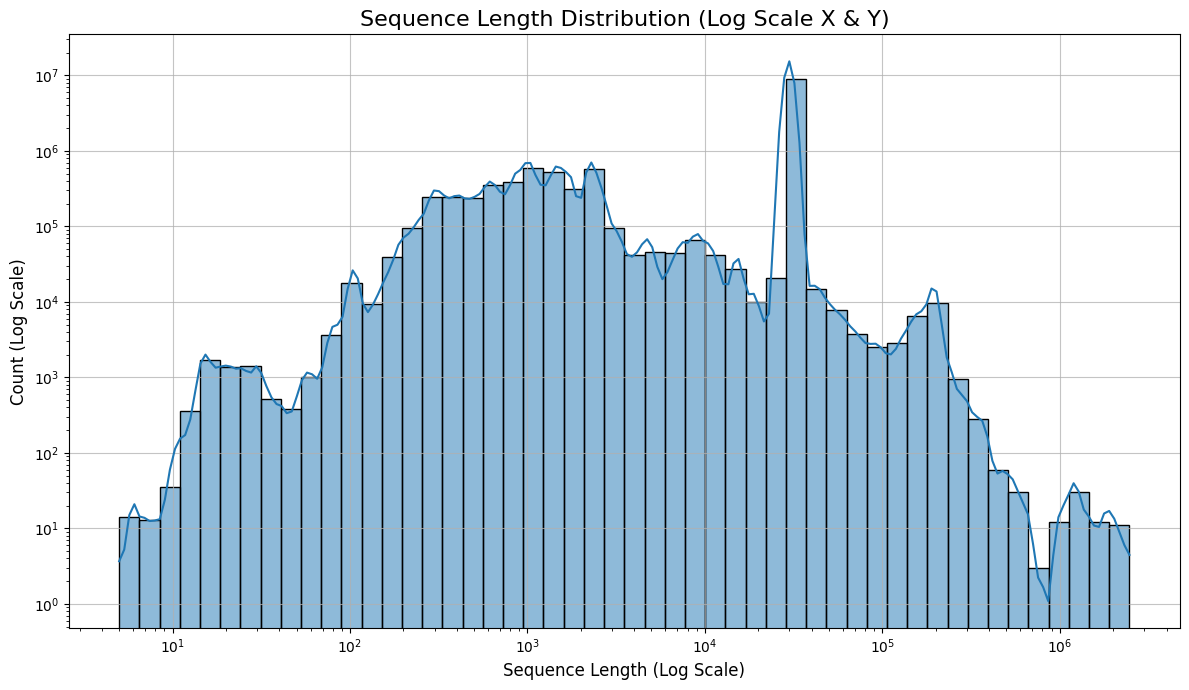

In [9]:
# --- Visualise sequence length distribution (log scale X & Y) ---
print("Generating sequence length distribution visualization")
plt.figure(figsize=(12, 7))
sns.histplot(df['sequence_length'], bins=50, kde=True, log_scale=True)
plt.title('Sequence Length Distribution (Log Scale X & Y)', fontsize=16)
plt.xlabel('Sequence Length (Log Scale)', fontsize=12)
plt.ylabel('Count (Log Scale)', fontsize=12)
plt.yscale('log') # Add log scale to the Y-axis
plt.grid(axis='both', alpha=0.75) # Grid for both axes
plt.tight_layout()
plt.show()
